# Evaluating Semantic ID Quality

Before fine-tuning an LLM on these semantic IDs, we check whether the trained RQ-VAE actually produced a *useful* discrete representation. Three questions matter here:

1. **Codebook health** — is the codebook well-distributed, or has it collapsed onto a handful of dominant codes?
2. **ID uniqueness** — how many items collide on the same base semantic ID, and how much does the disambiguation digit have to work?
3. **Semantic coherence** — do items that share an ID prefix actually resemble each other, or is the grouping arbitrary? This is the check that predicts whether the LLM has anything meaningful to learn from these tokens.

This notebook loads `data/output/semantic_ids.parquet` (id -> semantic ID mapping) and joins it with `data/clean_game_catalog.parquet` (for `Genres`/`Categories`, used only as an external validation signal — the RQ-VAE never saw this metadata during training).

In [1]:
import random
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

pd_colors = {
    "usage": "#0072B2",      # single hue for the codebook-usage small multiples
    "within_group": "#0072B2",
    "random": "#8C8C8C",     # neutral gray for the "chance" baseline
}

RNG_SEED = 0
plt.rcParams["figure.dpi"] = 100

## Load Data

`semantic_ids.parquet` holds one row per item: the 3 RQ-VAE codebook levels plus a 4th disambiguation digit (see `export_semantic_ids.py`). We join it to the catalog's `Genres`/`Categories` purely as an external check — genre similarity is a reasonable proxy for "these two games are actually alike."

In [2]:
semantic_ids = pl.read_parquet("../data/output/semantic_ids.parquet")
catalog = pl.read_parquet("../data/clean_game_catalog.parquet", columns=["id", "Name", "Genres", "Categories"])

df = semantic_ids.join(catalog, on="id", how="inner")

CODEBOOK_SIZE = int(max(df["semantic_id_0"].max(), df["semantic_id_1"].max(), df["semantic_id_2"].max()) + 1)
N_LEVELS = 3  # real RQ-VAE codebook levels; semantic_id_3 is the disambiguation digit, not a codebook

print(f"Items: {len(df):,}")
print(f"Codebook size (levels 0-2): {CODEBOOK_SIZE}")
print(f"Items with Genres available: {df['Genres'].is_not_null().sum():,} ({df['Genres'].is_not_null().mean():.1%})")

Items: 93,179
Codebook size (levels 0-2): 256
Items with Genres available: 88,380 (94.8%)


# 1. Codebook Usage

For each level, how many items landed on each of the 256 codes? A healthy codebook keeps this roughly even — a spike means a handful of codes are doing most of the work while the rest sit idle (index collapse). This is the same `codebook_max_share` diagnostic tracked during training (see [train_rqvae.py](../src/train_rqvae.py)), now computed on the full, final exported dataset instead of a single training batch.

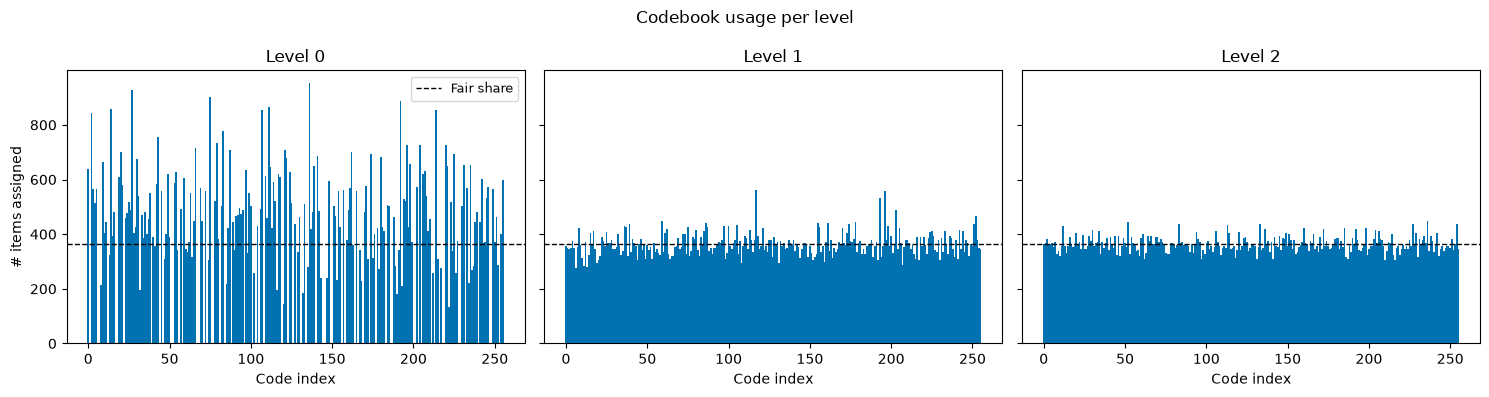

In [3]:
def usage_counts(level: int) -> np.ndarray:
    return np.bincount(df[f"semantic_id_{level}"].to_numpy(), minlength=CODEBOOK_SIZE)


fig, axes = plt.subplots(1, N_LEVELS, figsize=(15, 4), sharey=True)
for level, ax in enumerate(axes):
    counts = usage_counts(level)
    ax.bar(np.arange(CODEBOOK_SIZE), counts, width=1.0, color=pd_colors["usage"])
    ax.axhline(counts.sum() / CODEBOOK_SIZE, color="black", linewidth=1, linestyle="--", label="Fair share")
    ax.set_title(f"Level {level}")
    ax.set_xlabel("Code index")
    if level == 0:
        ax.set_ylabel("# items assigned")
        ax.legend(fontsize=9)

fig.suptitle("Codebook usage per level")
plt.tight_layout()
plt.show()

In [4]:
def normalized_entropy(counts: np.ndarray) -> float:
    """0 = all usage on one code, 1 = perfectly uniform across the codebook."""
    used = counts[counts > 0]
    p = used / used.sum()
    return float(-(p * np.log(p)).sum() / np.log(len(counts)))


summary_rows = []
for level in range(N_LEVELS):
    counts = usage_counts(level)
    summary_rows.append({
        "level": level,
        "codes_used": int((counts > 0).sum()),
        "utilization": (counts > 0).mean(),
        "max_code_share": counts.max() / counts.sum(),
        "normalized_entropy": normalized_entropy(counts),
    })

usage_summary = pl.DataFrame(summary_rows)
usage_summary

level,codes_used,utilization,max_code_share,normalized_entropy
i64,i64,f64,f64,f64
0,190,0.7421875,0.010217,0.93578
1,256,1.0,0.00601,0.998851
2,256,1.0,0.004797,0.999478


# 2. ID Uniqueness & Collisions

Two items can land on the same (level 0, level 1, level 2) tuple — `export_semantic_ids.py` appends a 4th disambiguation digit to guarantee every full ID is unique. Here we look at how much that digit actually has to do: how many items collide before disambiguation, and how large the worst collision groups get.

Base (3-level) IDs that were already unique: 87,068/89,645 groups
Items that needed the disambiguation digit: 6,111/93,179 (6.56%)
Largest collision group: 38 items (disambiguator range: 0-37)


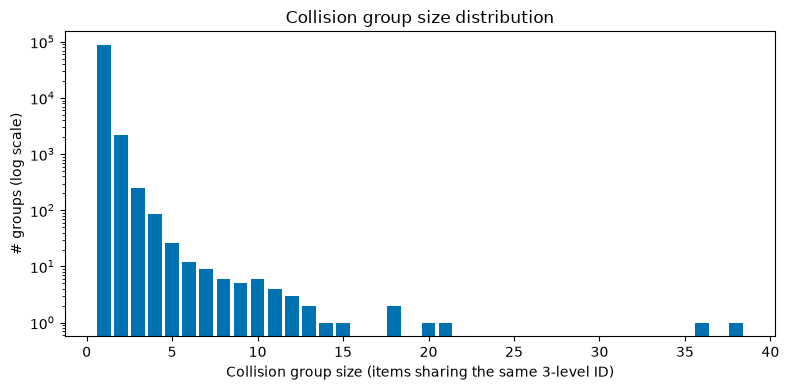

In [5]:
collision_sizes = (
    df.group_by(["semantic_id_0", "semantic_id_1", "semantic_id_2"])
    .len()
    .rename({"len": "group_size"})
)

n_unique_before_disambig = (collision_sizes["group_size"] == 1).sum()
n_items_colliding = len(df) - n_unique_before_disambig

print(f"Base (3-level) IDs that were already unique: {n_unique_before_disambig:,}/{len(collision_sizes):,} groups")
print(f"Items that needed the disambiguation digit: {n_items_colliding:,}/{len(df):,} ({n_items_colliding / len(df):.2%})")
print(f"Largest collision group: {collision_sizes['group_size'].max()} items (disambiguator range: 0-{df['semantic_id_3'].max()})")

fig, ax = plt.subplots(figsize=(8, 4))
sizes, counts = np.unique(collision_sizes["group_size"].to_numpy(), return_counts=True)
ax.bar(sizes, counts, color=pd_colors["usage"])
ax.set_yscale("log")
ax.set_xlabel("Collision group size (items sharing the same 3-level ID)")
ax.set_ylabel("# groups (log scale)")
ax.set_title("Collision group size distribution")
plt.tight_layout()
plt.show()

# 3. Semantic Coherence

Codebook balance and uniqueness only check the *mechanics* of the discrete bottleneck — they say nothing about whether items that share an ID prefix are actually similar games. If two unrelated games get the same level-0 code just because the codebook happened to balance that way, there's nothing for the LLM to learn from that digit.

**Method:** for each item, take its `Genres` as a set (e.g. `{Action, Indie, RPG}`) and compute the Jaccard similarity between pairs of items — `|intersection| / |union|`. Compare the similarity of pairs that **share a semantic ID prefix** against the similarity of **random pairs** (the chance baseline). If the RQ-VAE captured genuine structure, same-prefix pairs should be noticeably more similar than random pairs.

We check this at two granularities: level 0 alone (coarse, ~490 items/group on average) and levels 0+1 combined (finer, ~2-3 items/group).

In [6]:
# Only items with genre info can be scored; build a row-aligned list of genre
# sets and restrict everything below to that subset.
has_genres = df["Genres"].is_not_null()
scored = df.filter(has_genres)

genre_sets = [set(g.split(",")) for g in scored["Genres"].to_list()]
level0 = scored["semantic_id_0"].to_numpy()
level01 = list(zip(scored["semantic_id_0"].to_numpy(), scored["semantic_id_1"].to_numpy()))

print(f"Scoring coherence on {len(scored):,}/{len(df):,} items with known Genres")

Scoring coherence on 88,380/93,179 items with known Genres


In [7]:
def group_indices(keys) -> dict:
    """Maps each distinct key to the list of row positions sharing it."""
    groups = {}
    for i, key in enumerate(keys):
        groups.setdefault(key, []).append(i)
    return groups


def sample_pairs_within_groups(groups: dict, max_pairs_per_group: int, rng: random.Random) -> list:
    """All pairs for small groups; a random sample (without full enumeration) for large ones."""
    pairs = []
    for indices in groups.values():
        if len(indices) < 2:
            continue
        n_possible = len(indices) * (len(indices) - 1) // 2
        if n_possible <= max_pairs_per_group:
            pairs.extend(combinations(indices, 2))
        else:
            seen = set()
            while len(seen) < max_pairs_per_group:
                a, b = rng.sample(indices, 2)
                seen.add((min(a, b), max(a, b)))
            pairs.extend(seen)
    return pairs


def sample_random_pairs(n_items: int, n_pairs: int, rng: random.Random) -> list:
    pairs = []
    while len(pairs) < n_pairs:
        i, j = rng.randrange(n_items), rng.randrange(n_items)
        if i != j:
            pairs.append((i, j))
    return pairs


def jaccard_scores(pairs: list, sets: list) -> np.ndarray:
    scores = []
    for i, j in pairs:
        union = sets[i] | sets[j]
        if union:
            scores.append(len(sets[i] & sets[j]) / len(union))
    return np.array(scores)

In [8]:
rng = random.Random(RNG_SEED)

random_pairs = sample_random_pairs(len(scored), n_pairs=50_000, rng=rng)
random_scores = jaccard_scores(random_pairs, genre_sets)

level0_groups = group_indices(level0)
level0_pairs = sample_pairs_within_groups(level0_groups, max_pairs_per_group=300, rng=rng)
level0_scores = jaccard_scores(level0_pairs, genre_sets)

level01_groups = group_indices(level01)
level01_pairs = sample_pairs_within_groups(level01_groups, max_pairs_per_group=300, rng=rng)
level01_scores = jaccard_scores(level01_pairs, genre_sets)

for name, scores in [("Random pairs", random_scores), ("Same level-0", level0_scores), ("Same level-0+1", level01_scores)]:
    print(f"{name:>16}: n={len(scores):>7,}  mean Jaccard={scores.mean():.3f}  median={np.median(scores):.3f}")

print(f"\nLift vs. random -> level-0: {level0_scores.mean() / random_scores.mean():.2f}x, level-0+1: {level01_scores.mean() / random_scores.mean():.2f}x")

    Random pairs: n= 50,000  mean Jaccard=0.263  median=0.250
    Same level-0: n= 54,651  mean Jaccard=0.448  median=0.400
  Same level-0+1: n=171,338  mean Jaccard=0.608  median=0.600

Lift vs. random -> level-0: 1.71x, level-0+1: 2.31x


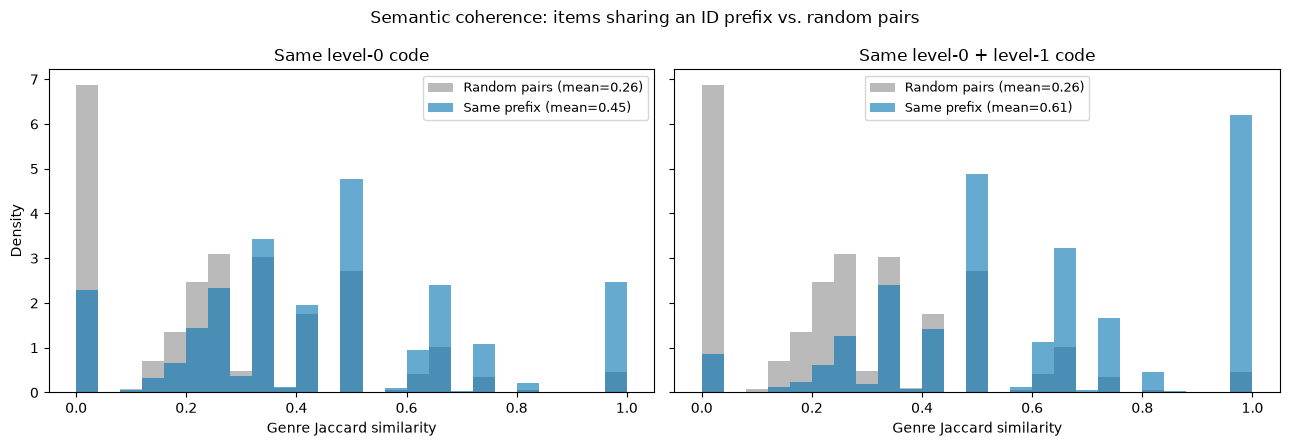

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
bins = np.linspace(0, 1, 26)

for ax, scores, title in [
    (axes[0], level0_scores, "Same level-0 code"),
    (axes[1], level01_scores, "Same level-0 + level-1 code"),
]:
    ax.hist(random_scores, bins=bins, density=True, alpha=0.6, color=pd_colors["random"], label=f"Random pairs (mean={random_scores.mean():.2f})")
    ax.hist(scores, bins=bins, density=True, alpha=0.6, color=pd_colors["within_group"], label=f"Same prefix (mean={scores.mean():.2f})")
    ax.set_xlabel("Genre Jaccard similarity")
    ax.set_title(title)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Density")
fig.suptitle("Semantic coherence: items sharing an ID prefix vs. random pairs")
plt.tight_layout()
plt.show()

### Eyeball check

Numbers aside, it's worth just reading a sample. Below are items sharing a single level-0+level-1 prefix (a mid-sized, non-cherry-picked group) — if the ID space is meaningful, these should visibly cluster by genre.

In [10]:
# Pick one mid-sized, non-cherry-picked level-0+level-1 group to read through.
group_sizes_01 = (
    df.group_by(["semantic_id_0", "semantic_id_1"])
    .len()
    .filter(pl.col("len") >= 5)
    .sort("len")
)
example_l0, example_l1, example_size = group_sizes_01.row(len(group_sizes_01) // 2)
print(f"Level-0={example_l0}, Level-1={example_l1}, group size={example_size}")

df.filter(
    (pl.col("semantic_id_0") == example_l0) & (pl.col("semantic_id_1") == example_l1)
).select(["Name", "Genres"])

Level-0=225, Level-1=52, group size=6


Name,Genres
str,str
"""Apollyon: River of Life""","""Action,Adventure,Indie,RPG,Str…"
"""The Fading Worlds""","""Action,Adventure,RPG"""
"""勇者屠龙 之 永恒幻想""","""Adventure,Casual,RPG"""
"""Soulivion""","""Action,RPG"""
"""Overlord™: Raising Hell""","""RPG"""
"""Dreams and Nightmares""","""Action,Adventure,RPG,Free To P…"


# Summary

Fill in after running against your final checkpoint's export:

- **Codebook usage**: check `usage_summary` above — `max_code_share` close to `1/codebook_size` and `normalized_entropy` close to 1.0 for every level means no collapse (compare against the ~99.6% single-code share seen before the dominance-reset fix).
- **Uniqueness**: the % of items needing the disambiguation digit, and how large the worst collision groups get — a large fraction needing disambiguation suggests the 3 levels aren't carrying enough information yet (could mean too few levels, too small a codebook, or the encoder bottleneck is too tight).
- **Semantic coherence**: the lift numbers (same-prefix mean Jaccard ÷ random-pair mean Jaccard) are the key verdict. A lift near 1.0x means the ID space is arbitrary with respect to genre — no better than a random hash — and fine-tuning on it is unlikely to help. A lift meaningfully above 1x (and a visibly right-shifted histogram) means the codes are capturing real structure.

If coherence looks weak despite healthy codebook usage, that points at the *encoder*, not the codebook — e.g. `codebook_embedding_dim` too small, or the reconstruction task not being informative enough to force genre-relevant information through the bottleneck.